In [2]:
#importing relavet libs
import ast
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#loading spesific dataset
from datasets import load_dataset
dataset = load_dataset('lukebarousse/data_jobs')

#changing to data frame
df = dataset['train'].to_pandas()

#cleaning data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)



In [3]:
#cleaning data for analys
df_trending_skills = df.copy()
df_trending_skills = df_trending_skills[df_trending_skills['job_title_short'] == 'Data Analyst'] #sorts for Data Analyst jobs
df_trending_skills = df_trending_skills[df_trending_skills['job_skills'].notna()] #taked off nan vakus from skills coulmn
df_trending_skills['job_posted_month'] = df_trending_skills['job_posted_date'].dt.strftime('%b') #add month row to df
df_trending_skills = df_trending_skills.explode('job_skills') #explode list of job skills
df_trending_skills['job_skills'] = df_trending_skills['job_skills'].astype(str) #turns to str (in case...)


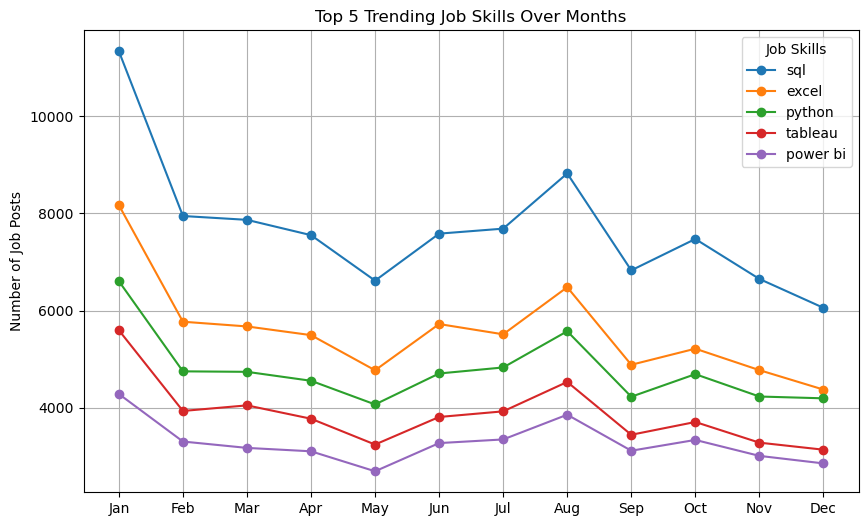

In [12]:
pivot_trending_skills = df_trending_skills.pivot_table(index='job_posted_month', columns='job_skills', aggfunc='size', fill_value=0)

# 1. Make sure months are sorted chronologically
pivot_trending_skills = pivot_trending_skills.sort_index()

# 2. Select only top 5 skills by total counts
top_skills = pivot_trending_skills.sum().sort_values(ascending=False).head(5).index
pivot_top5 = pivot_trending_skills[top_skills]

# Define month order
all_months_month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Reindex pivot table to chronological month order (only keeps months present in data)
pivot_top5 = pivot_top5.reindex([m for m in all_months_month_order if m in pivot_top5.index])

# 3. Plot line chart
ax = pivot_top5.plot(kind='line', marker='o', figsize=(10,6))

# Force all months to show on x-axis
ax.set_xticks(range(len(all_months_month_order)))
ax.set_xticklabels(all_months_month_order)

plt.xlabel('')
plt.ylabel('Number of Job Posts')
plt.title('Top 5 Trending Job Skills Over Months')
plt.legend(title='Job Skills')
plt.grid(True)
plt.show()